# Explainability Attempt — Named Physical Features

Christina's requirement, quoted directly from her guidance on this engagement:

> *"The customer would prefer to have explainable models - in that the model prediction
> can be linked to specific physical features gathered from the detector signals (e.g.
> current waveform statistics, or a specific emission wavelength, or etc.)"*

`porosity_pipeline.ipynb`'s best result (`IR_pix`/ridge, all 1,024 raw thermal pixels)
does not meet this requirement — it can't be described in terms of named physical
features, and the pixel geometry isn't confirmed. This notebook is a direct, honest
answer to the question that gap leaves open: **what happens if we build exactly the kind
of model Christina asked for, using the same rigor as everything else?**

Four named, physically-interpretable feature groups are built and tested here, matching
her own examples:
- **Current waveform statistics** (her example, verbatim) — amplitude of the `I_t` waveform.
- **A specific emission wavelength** (her example, verbatim) — intensity at physically
  prominent OES peaks, selected without looking at porosity (though still using all 20
  samples' sensor values to pick the wavelengths -- see Section 2's disclosure).
- **Voltage waveform statistics, thermal summary statistics, and a resistance estimate
  (V/I)** — the same kind of named feature, extended to the other measurement types and a
  physically motivated derived quantity, for completeness (Section 6).

Every result here is checked against baseline under 5-fold and leave-one-out CV, with the
outer held-out sample never used for model fitting -- see Sections 2 and 4 for two specific
disclosures on what that does and doesn't fully cover.

**Assumptions and scope:** this notebook builds on the same data, aggregation, and customer
clarifications as the primary pipeline -- see `porosity_pipeline.ipynb`'s "Customer
clarifications, assumptions, and scope" section (near the top of that notebook) for the
full list; it isn't repeated here.


In [1]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.colors as pc
from pathlib import Path
from scipy.signal import find_peaks
from sklearn.model_selection import KFold, LeaveOneOut
from sklearn.linear_model import RidgeCV, LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error
import subprocess, os, sys, tempfile
from IPython.display import Image, display
import warnings

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
DATA = Path("data")

def show_figure_as_image(html_path, width=1000, height=650, enable_screenshot=True):
    """Optional: embed a static PNG snapshot of the interactive Plotly HTML as cell output.
    Requires Playwright with a Chromium browser; skips gracefully (prints a notice) if
    unavailable, rather than failing the notebook run. The standalone interactive .html
    file referenced by html_path is always produced regardless of this step -- open it
    directly in a browser if the embedded screenshot isn't shown."""
    if not enable_screenshot:
        print(f"(screenshot capture disabled -- open {html_path} directly for the interactive figure)")
        return
    abs_path = os.path.abspath(html_path)
    out_path = os.path.join(tempfile.gettempdir(), f"_nb_fig_{os.getpid()}.png")
    candidate_chromium = os.environ.get("PLAYWRIGHT_CHROMIUM_PATH", "/opt/pw-browsers/chromium")
    script = (
        "import os\n"
        "from playwright.sync_api import sync_playwright\n"
        "with sync_playwright() as p:\n"
        f"    candidate = {candidate_chromium!r}\n"
        "    kwargs = {'executable_path': candidate} if os.path.exists(candidate) else {}\n"
        "    browser = p.chromium.launch(**kwargs)\n"
        f"    page = browser.new_page(viewport={{'width': {width}, 'height': {height}}})\n"
        f"    page.goto('file://{abs_path}')\n"
        "    page.wait_for_timeout(1200)\n"
        f"    page.screenshot(path={out_path!r}, full_page=True)\n"
        "    browser.close()\n"
    )
    try:
        result = subprocess.run([sys.executable, "-c", script], capture_output=True, text=True, timeout=60)
        if result.returncode != 0 or not os.path.exists(out_path):
            err = (result.stderr or "unknown error")[-300:]
            print(f"(screenshot capture unavailable -- Playwright/Chromium not found or failed "
                  f"({err}); open {html_path} directly for the interactive figure)")
            return
        with open(out_path, "rb") as f:
            display(Image(data=f.read()))
    except Exception as e:
        print(f"(screenshot capture unavailable ({e}); open {html_path} directly for the interactive figure)")


## 1. Load and aggregate data (same as the primary pipeline)

In [2]:
sample_info = pd.read_csv(DATA / "Sample_Info.csv", index_col=0)
measurement_parts = [
    "Measurement_Data_part_1_samples_0-6.csv",
    "Measurement_Data_part_2_samples_7-13.csv",
    "Measurement_Data_part_3_samples_14-19.csv",
]
meas = pd.concat([pd.read_csv(DATA / fn, index_col=0) for fn in measurement_parts], ignore_index=True)
oes_wavelengths = pd.read_csv(DATA / "OES_Wavelengths.csv", index_col=0)

feat_cols = [c for c in meas.columns if c not in ("sample_id", "measurement_id")]
oes_cols = [c for c in feat_cols if c.startswith("OES_bin")]
vt_cols = [c for c in feat_cols if c.startswith("V_t")]
it_cols = [c for c in feat_cols if c.startswith("I_t")]
ir_cols = [c for c in feat_cols if c.startswith("IR_pix")]

grp = meas.groupby("sample_id")
sample_feats = grp[feat_cols].mean().reset_index()
data = sample_info.merge(sample_feats, on="sample_id", how="left").sort_values("sample_id").reset_index(drop=True)
y = data["porosity"].values
sample_ids = data["sample_id"].values
print(f"sample-level table: {data.shape}")


sample-level table: (20, 2307)


## 2. Build named, physically-interpretable features

**A specific emission wavelength (OES peaks):** peaks are selected from the *mean OES
spectrum averaged across all 20 samples* — a target-independent selection, since it never
looks at porosity. Each sample's intensity at those fixed wavelengths becomes a named
feature ("intensity at 322nm," etc.), not a raw bin index.

**Disclosure:** this selection never uses porosity labels, but it does use every
sample's own OES sensor values (the mean spectrum is averaged across all 20 samples,
including whichever ones later land in a CV test fold). So the OES and combined
named-feature results below (Sections 3-5) do not evaluate a fully training-only
feature-selection procedure -- the *identity* of the wavelengths was chosen with
knowledge of every sample's spectrum, even though its *relationship to porosity* was
not. The size of this effect hasn't been quantified here; a stricter validation would
re-select peaks from the training fold's spectra only. This limitation is specific to
the OES peak selection and does not affect the thermal-only or electrical-only feature
groups, which use fixed, already-defined summary statistics rather than selected bins.


In [3]:
mean_spectrum = data[oes_cols].values.mean(axis=0)
peak_idx, props = find_peaks(mean_spectrum, prominence=0.3)
# keep the 8 most prominent peaks, sorted by wavelength for readability
top_peak_idx = peak_idx[np.argsort(-props["prominences"])][:8]
top_peak_idx = np.sort(top_peak_idx)
peak_wavelengths = oes_wavelengths.loc[oes_wavelengths["Bin Number"].isin(top_peak_idx), "Wavelength (nm)"].values

print(f"Selected {len(top_peak_idx)} OES peaks (target-independent, from mean spectrum):")
for idx, wl in zip(top_peak_idx, peak_wavelengths):
    print(f"  bin {idx:3d}  ->  {wl:.2f} nm  (mean intensity {mean_spectrum[idx]:.3f})")

oes_peak_cols = [f"OES_bin_{i}" for i in top_peak_idx]
oes_peak_features = data[oes_peak_cols].copy()
oes_peak_features.columns = [f"OES_{wl:.0f}nm" for wl in peak_wavelengths]


Selected 8 OES peaks (target-independent, from mean spectrum):
  bin  10  ->  335.29 nm  (mean intensity 6.741)
  bin  16  ->  356.47 nm  (mean intensity 4.973)
  bin  96  ->  638.82 nm  (mean intensity 1.902)
  bin 101  ->  656.47 nm  (mean intensity 7.298)
  bin 104  ->  667.06 nm  (mean intensity 3.756)
  bin 115  ->  705.88 nm  (mean intensity 6.922)
  bin 135  ->  776.47 nm  (mean intensity 1.449)
  bin 221  ->  1080.00 nm  (mean intensity 3.417)


**Current and voltage waveform statistics** (Christina's own example for the electrical
channel): amplitude (half the peak-to-peak swing) of each waveform, computed per
measurement and averaged over each sample's 100 repeats.


In [4]:
meas_eng = pd.DataFrame({"sample_id": meas["sample_id"]})
meas_eng["voltage_amplitude"] = (meas[vt_cols].max(axis=1) - meas[vt_cols].min(axis=1)) / 2.0
meas_eng["current_amplitude"] = (meas[it_cols].max(axis=1) - meas[it_cols].min(axis=1)) / 2.0
meas_eng["thermal_mean"] = meas[ir_cols].mean(axis=1)

electrical_thermal = meas_eng.groupby("sample_id")[["voltage_amplitude", "current_amplitude", "thermal_mean"]].mean()
electrical_thermal = electrical_thermal.reset_index(drop=True)
electrical_thermal["thermal_amplitude"] = data[ir_cols].values.std(axis=1)  # spatial contrast per sample, already sample-level

explainable_features = pd.concat([oes_peak_features.reset_index(drop=True), electrical_thermal], axis=1)
print(f"Named feature set: {list(explainable_features.columns)}")
explainable_features.insert(0, "sample_id", sample_ids)
explainable_features.insert(1, "porosity", y)
explainable_features


Named feature set: ['OES_335nm', 'OES_356nm', 'OES_639nm', 'OES_656nm', 'OES_667nm', 'OES_706nm', 'OES_776nm', 'OES_1080nm', 'voltage_amplitude', 'current_amplitude', 'thermal_mean', 'thermal_amplitude']


,sample_id,porosity,OES_335nm,OES_356nm,OES_639nm,OES_656nm,OES_667nm,OES_706nm,OES_776nm,OES_1080nm,voltage_amplitude,current_amplitude,thermal_mean,thermal_amplitude
0,0,27.36,9.217069,6.557008,2.466680,9.581771,5.767671,8.991508,1.214482,4.507237,5.780081,7.729218,2.740562,0.718576
1,1,26.89,3.070514,2.055497,1.404549,3.497997,2.148415,3.019778,1.530649,2.461382,6.651305,3.078583,0.057633,0.132852
2,2,20.26,3.650010,2.911978,2.833576,4.806784,5.394959,4.465450,2.442819,5.911908,5.922362,6.148947,0.259463,0.311073
3,3,28.91,4.411705,3.281791,3.117779,5.148006,6.329063,4.640233,1.411115,5.965366,7.211104,3.935323,0.464669,0.488943
4,4,31.02,10.027860,7.474868,2.514467,10.593677,5.668144,10.421024,1.063612,4.702732,5.270283,10.117863,3.290202,0.659969
5,5,28.34,10.322442,7.553296,1.221713,11.253218,1.901091,10.773583,1.508101,1.866350,6.388102,4.230826,3.545944,0.573330
6,6,26.24,3.267734,2.537215,1.995894,3.339941,4.376291,2.803799,1.080058,3.740592,6.788263,5.186725,0.122329,0.223655
7,7,28.55,10.200117,7.350085,1.504417,10.659337,3.078740,10.375119,1.073696,2.154827,5.231656,8.942841,3.502021,0.512124
8,8,25.95,7.395309,5.549036,1.565024,7.630524,3.524920,7.169093,1.234369,3.063895,5.394804,7.979035,2.090023,0.622322
9,9,19.96,5.863405,4.080290,0.916461,5.756279,1.933891,5.335218,1.104301,1.296950,4.990466,10.441917,1.247257,0.527313


## 3. Descriptive correlation with porosity — every named feature, individually

In [5]:
from scipy.stats import pearsonr
rows = []
for col in explainable_features.columns:
    if col in ("sample_id", "porosity"):
        continue
    r, p = pearsonr(explainable_features[col].values, y)
    rows.append({"feature": col, "r": round(r, 3), "p": round(p, 3)})
corr_df = pd.DataFrame(rows).sort_values("r", key=abs, ascending=False).reset_index(drop=True)
corr_df


,feature,r,p
0,OES_706nm,0.474,0.035
1,OES_656nm,0.470,0.037
2,OES_356nm,0.440,0.052
3,OES_335nm,0.433,0.056
4,thermal_mean,0.408,0.074
5,thermal_amplitude,0.393,0.087
6,voltage_amplitude,0.362,0.117
7,OES_639nm,0.263,0.263
8,OES_667nm,0.247,0.293
9,OES_1080nm,0.220,0.351


## 4. Cross-validated accuracy — the honest test

Each named feature group, and all of them combined, run through the identical
methodology as the primary pipeline: baseline comparison, 5-fold and LOO CV, ridge
(regularized) and plain OLS (since this feature set is small enough — 12 features
at most — that overfitting risk from regularization choice itself is worth checking both
ways).

**Two disclosures on what "no leakage" does and doesn't cover here:**
- *Scaling and ridge tuning are not fully re-nested.* `StandardScaler` is fit on each outer
  training fold only (never the held-out point), so the outer held-out sample is protected.
  But the scaler is fit once per fold, before `RidgeCV`'s own internal leave-one-out search
  runs on the already-scaled training data -- that internal search isn't refitting the
  scaler within each of its own internal splits. This is a different modeling pipeline from
  the main thermal reference model in `porosity_pipeline.ipynb` (which is unstandardized),
  so results here and there are not a clean like-for-like ablation of only the feature
  representation.
- *The tuning objective is MSE, not MAE/MAPE.* `RidgeCV(cv=None)` selects its regularization
  strength using efficient internal leave-one-out mean squared error, the library default.
  Final performance is then reported using MAE and MAPE below -- the ridge penalty was not
  optimized for either of those reported metrics directly.


In [6]:
def make_cv(scheme):
    return KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE) if scheme == "five_fold" else LeaveOneOut()

def mape(y_true, y_pred):
    return np.mean(np.abs((y_pred - y_true) / y_true)) * 100

def evaluate(X, y, scheme, model_name):
    n = len(y)
    cv = make_cv(scheme)
    preds = np.zeros(n)
    for train_idx, test_idx in cv.split(X):
        if model_name == "baseline":
            preds[test_idx] = y[train_idx].mean()
            continue
        if model_name == "ridge":
            model = Pipeline([("scale", StandardScaler()), ("ridge", RidgeCV(alphas=np.logspace(-2, 5, 40), cv=None))])
        elif model_name == "ols":
            model = Pipeline([("scale", StandardScaler()), ("lr", LinearRegression())])
        model.fit(X[train_idx], y[train_idx])
        preds[test_idx] = model.predict(X[test_idx])
    return mean_absolute_error(y, preds), mape(y, preds)

groups = {
    "OES peaks (8 wavelengths)": [c for c in explainable_features.columns if c.startswith("OES_")],
    "Electrical (V+I amplitude)": ["voltage_amplitude", "current_amplitude"],
    "Thermal summary (2 stats)": ["thermal_mean", "thermal_amplitude"],
    "All named features combined": [c for c in explainable_features.columns if c not in ("sample_id", "porosity")],
}

results_rows = []
for gname, cols in groups.items():
    X = explainable_features[cols].values
    for scheme in ["five_fold", "loo"]:
        for model_name in ["ridge", "ols"]:
            mae, mp = evaluate(X, y, scheme, model_name)
            results_rows.append({"feature_group": gname, "n_features": len(cols), "scheme": scheme,
                                  "model": model_name, "MAE": round(mae, 3), "MAPE": round(mp, 2)})

baseline_rows = [{"feature_group": "baseline (no features)", "n_features": 0, "scheme": s, "model": "-",
                   "MAE": round(evaluate(explainable_features[["thermal_mean"]].values, y, s, "baseline")[0], 3),
                   "MAPE": round(evaluate(explainable_features[["thermal_mean"]].values, y, s, "baseline")[1], 2)}
                  for s in ["five_fold", "loo"]]

results_df = pd.DataFrame(baseline_rows + results_rows)
results_df


,feature_group,n_features,scheme,model,MAE,MAPE
0,baseline (no features),0,five_fold,-,2.445,9.70
1,baseline (no features),0,loo,-,2.503,9.91
2,OES peaks (8 wavelengths),8,five_fold,ridge,2.776,10.92
3,OES peaks (8 wavelengths),8,five_fold,ols,4.332,17.03
4,OES peaks (8 wavelengths),8,loo,ridge,2.937,11.55
5,OES peaks (8 wavelengths),8,loo,ols,3.316,12.98
6,Electrical (V+I amplitude),2,five_fold,ridge,2.581,10.21
7,Electrical (V+I amplitude),2,five_fold,ols,2.750,10.86
8,Electrical (V+I amplitude),2,loo,ridge,2.661,10.49
9,Electrical (V+I amplitude),2,loo,ols,2.712,10.65


## 5. The comparison that matters: explainable features vs. the raw-pixel model

Reference numbers from `porosity_pipeline.ipynb`: baseline MAE 2.45 (5-fold) / 2.50
(LOO); `IR_pix`/ridge (not explainable) MAE 2.27 (5-fold) / 2.02 (LOO).


In [7]:
best_explainable = results_df[results_df["feature_group"] != "baseline (no features)"].sort_values("MAE").iloc[0]
print("Best explainable-feature result found:")
print(best_explainable)
print()
print("Reference (from porosity_pipeline.ipynb):")
print("  baseline        five_fold=2.445  loo=2.503")
print("  IR_pix / ridge  five_fold=2.270  loo=2.021   <- NOT explainable, best overall result")


Best explainable-feature result found:
feature_group    All named features combined
n_features                                12
scheme                                   loo
model                                  ridge
MAE                                    2.363
MAPE                                    9.19
Name: 16, dtype: object

Reference (from porosity_pipeline.ipynb):
  baseline        five_fold=2.445  loo=2.503
  IR_pix / ridge  five_fold=2.270  loo=2.021   <- NOT explainable, best overall result


## 6. A physically motivated variant: resistance (V/I)

Porosity is also a reasonable candidate to affect electrical resistance directly (a more
porous sample has less solid conducting material along the current path), so a
resistance-like quantity derived from the voltage and current waveforms is worth testing
alongside the amplitude and correlation statistics already tried above.

**Pointwise division (`V_t / I_t` at each of the 512 time points) is not safe here**:
both waveforms oscillate around zero (roughly 20 sign changes per 512-point trace, with
about 9% of `I_t` values near zero), so dividing point-by-point produces huge, unstable,
sign-flipping values right at the current's zero-crossings -- not a meaningful signal.
Instead, three summary-level resistance estimates are computed per measurement (then
averaged to sample level, same aggregation as everywhere else): the ratio of RMS values
(the standard way to summarize the magnitude of an oscillating quantity), the ratio of
amplitudes (already used for `voltage_amplitude`/`current_amplitude` above), and the
ratio of mean absolute values.

In [8]:
vt_arr = meas[vt_cols].values
it_arr = meas[it_cols].values

rms_v = np.sqrt(np.mean(vt_arr**2, axis=1))
rms_i = np.sqrt(np.mean(it_arr**2, axis=1))
r_rms = rms_v / rms_i

amp_v = (vt_arr.max(axis=1) - vt_arr.min(axis=1)) / 2.0
amp_i = (it_arr.max(axis=1) - it_arr.min(axis=1)) / 2.0
r_amp = amp_v / amp_i

meanabs_v = np.mean(np.abs(vt_arr), axis=1)
meanabs_i = np.mean(np.abs(it_arr), axis=1)
r_meanabs = meanabs_v / meanabs_i

resistance_meas = pd.DataFrame({"sample_id": meas["sample_id"], "r_rms": r_rms, "r_amp": r_amp, "r_meanabs": r_meanabs})
resistance_features = resistance_meas.groupby("sample_id").mean().reset_index(drop=True)

print("Correlation with porosity:")
for col in ["r_rms", "r_amp", "r_meanabs"]:
    r, p = pearsonr(resistance_features[col].values, y)
    print(f"  {col:12s} r={r:+.3f}  p={p:.3f}")

resistance_rows = []
res_groups = {
    "r_rms alone": ["r_rms"], "r_amp alone": ["r_amp"], "r_meanabs alone": ["r_meanabs"],
    "all three resistance features": ["r_rms", "r_amp", "r_meanabs"],
}
for gname, cols in res_groups.items():
    X = resistance_features[cols].values
    for scheme in ["five_fold", "loo"]:
        for model_name in ["ridge", "ols"]:
            mae, mp = evaluate(X, y, scheme, model_name)
            resistance_rows.append({"feature_group": gname, "n_features": len(cols), "scheme": scheme,
                                     "model": model_name, "MAE": round(mae, 3), "MAPE": round(mp, 2)})
resistance_df = pd.DataFrame(resistance_rows)
resistance_df

Correlation with porosity:
  r_rms        r=+0.063  p=0.791
  r_amp        r=+0.251  p=0.286
  r_meanabs    r=-0.026  p=0.914


,feature_group,n_features,scheme,model,MAE,MAPE
0,r_rms alone,1,five_fold,ridge,2.445,9.70
1,r_rms alone,1,five_fold,ols,2.608,10.34
2,r_rms alone,1,loo,ridge,2.503,9.91
3,r_rms alone,1,loo,ols,2.643,10.45
4,r_amp alone,1,five_fold,ridge,2.549,10.07
5,r_amp alone,1,five_fold,ols,2.494,9.81
6,r_amp alone,1,loo,ridge,2.607,10.26
7,r_amp alone,1,loo,ols,2.608,10.21
8,r_meanabs alone,1,five_fold,ridge,2.445,9.70
9,r_meanabs alone,1,five_fold,ols,2.565,10.21


**The three tested voltage/current summary ratios did not demonstrate a meaningful
improvement over the constant baseline in these evaluations.** Their descriptive
correlations with porosity were approximately 0.063 (RMS ratio), 0.251 (amplitude ratio),
and -0.026 (mean-\|value\| ratio). The amplitude ratio had a larger absolute correlation
than `current_amplitude` alone (r=-0.21, Section 3), but this did not translate into
improved prediction performance: under cross-validation, none of the three beat baseline
(5-fold MAE 2.445, LOO MAE 2.503) in either scheme; ridge on `r_rms` alone regresses
essentially to the baseline itself (its near-zero correlation gets shrunk toward a flat
prediction), and combining all three together is worse than any of them alone -- the same
"too many weak, noisy features for 20 samples" overfitting pattern seen throughout this
analysis.

These findings concern the particular ratio features and models tested here. They do not
establish that other electrical representations would be uninformative.

## 7. A different question: what does the *winning* model actually rely on?

Sections 2-6 asked "can an alternative, explainable-feature model match the winning
model's accuracy?" (no). That's a different question from **"which specific pixels does
the winning model (`IR_pix`/ridge, all 1,024 raw pixels) actually rely on?"** — not a new
model, an interpretation of the one already in use. This doesn't require a new predictive
test, just inspecting the fitted ridge weights.

Two checks: (1) ridge coefficient magnitude from a single fit on all 20 samples, and (2)
whether the same pixels show up as important across all 20 leave-one-out refits — a
stability check, since a ridge fit on 19 samples can look meaningfully different from one
on 20, and an "important pixel" that isn't stable across folds isn't a trustworthy one to
report to a customer.


In [9]:
from sklearn.linear_model import RidgeCV as _RidgeCV
from sklearn.model_selection import LeaveOneOut as _LOO

ir_cols_full = [c for c in data.columns if c.startswith("IR_pix")]
X_ir = data[ir_cols_full].values
alphas = np.logspace(-2, 5, 40)

# (1) single fit on all 20 samples -- the "final" model as it would actually be deployed
final_model = _RidgeCV(alphas=alphas, cv=None).fit(X_ir, y)
coefs = final_model.coef_
top20_idx = np.argsort(-np.abs(coefs))[:20]

print("Top 20 pixels by |ridge coefficient| (single fit on all 20 samples):")
for rank, idx in enumerate(top20_idx, 1):
    print(f"  #{rank:2d}  pixel {idx:4d}  coef={coefs[idx]:+.4f}")

# (2) stability across all 20 LOO refits: does the same pixel keep showing up as important?
loo = _LOO()
top20_counts = np.zeros(len(ir_cols_full), dtype=int)
for train_idx, _ in loo.split(X_ir):
    m = _RidgeCV(alphas=alphas, cv=None).fit(X_ir[train_idx], y[train_idx])
    fold_top20 = np.argsort(-np.abs(m.coef_))[:20]
    top20_counts[fold_top20] += 1

stability_df = pd.DataFrame({
    "pixel_index": np.arange(len(ir_cols_full)),
    "final_fit_coef": coefs,
    "abs_coef": np.abs(coefs),
    "top20_count_across_20_loo_folds": top20_counts,
}).sort_values("abs_coef", ascending=False).reset_index(drop=True)

print("\nTop 15 pixels, with how many of the 20 LOO refits also ranked them top-20:")
stability_df.head(15)


Top 20 pixels by |ridge coefficient| (single fit on all 20 samples):
  # 1  pixel  375  coef=-0.0856
  # 2  pixel  343  coef=-0.0840
  # 3  pixel  374  coef=-0.0782
  # 4  pixel  342  coef=-0.0762
  # 5  pixel  376  coef=-0.0744
  # 6  pixel  407  coef=-0.0737
  # 7  pixel  344  coef=-0.0733
  # 8  pixel  406  coef=-0.0704
  # 9  pixel  311  coef=-0.0671
  #10  pixel  408  coef=-0.0643
  #11  pixel  310  coef=-0.0606
  #12  pixel  373  coef=-0.0587
  #13  pixel  312  coef=-0.0583
  #14  pixel  405  coef=-0.0582
  #15  pixel  438  coef=-0.0581
  #16  pixel  439  coef=-0.0578
  #17  pixel  341  coef=-0.0536
  #18  pixel  159  coef=+0.0519
  #19  pixel  345  coef=-0.0509
  #20  pixel  377  coef=-0.0507

Top 15 pixels, with how many of the 20 LOO refits also ranked them top-20:


,pixel_index,final_fit_coef,abs_coef,top20_count_across_20_loo_folds
0,375,-0.085571,0.085571,19
1,343,-0.083974,0.083974,19
2,374,-0.078236,0.078236,19
3,342,-0.076233,0.076233,18
4,376,-0.074356,0.074356,17
5,407,-0.073717,0.073717,19
6,344,-0.073337,0.073337,17
7,406,-0.070390,0.070390,18
8,311,-0.067078,0.067078,16
9,408,-0.064310,0.064310,16


## 8. Do the important pixels cluster, or scatter randomly?

The pixel geometry (row/column layout of the flattened image) is unconfirmed, so "this is
the top-left corner" can't be said. But if the important pixels cluster in *contiguous
index ranges* rather than scattering randomly across all 1,024, that's suggestive of a
real spatial region mattering (assuming a standard row-major flattening, nearby indices
are usually nearby pixels) — a partial, honest step toward spatial interpretation even
without confirmed geometry.


Top-20 pixel indices, sorted: [np.int64(159), np.int64(310), np.int64(311), np.int64(312), np.int64(341), np.int64(342), np.int64(343), np.int64(344), np.int64(345), np.int64(373), np.int64(374), np.int64(375), np.int64(376), np.int64(377), np.int64(405), np.int64(406), np.int64(407), np.int64(408), np.int64(438), np.int64(439)]
Gaps between consecutive top-20 indices: [np.int64(151), np.int64(1), np.int64(1), np.int64(29), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(28), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(28), np.int64(1), np.int64(1), np.int64(1), np.int64(30), np.int64(1)]

Median gap: 1  (out of 1024 total pixels -- 'random scatter' would average ~51 apart if evenly spread)


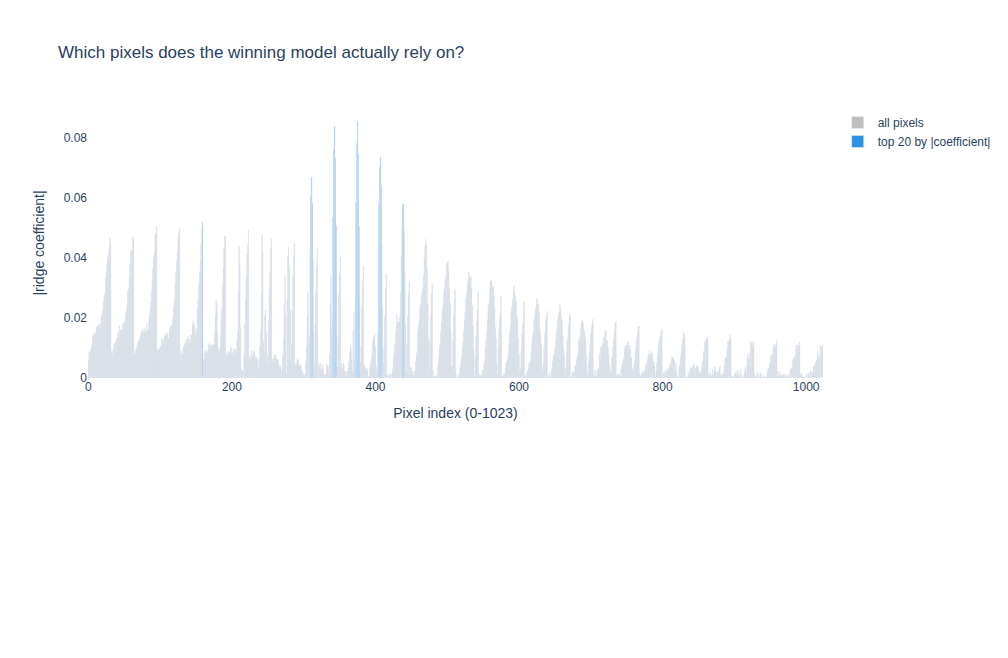

In [10]:
top20_pixel_indices = np.sort(top20_idx)
gaps = np.diff(top20_pixel_indices)
print("Top-20 pixel indices, sorted:", list(top20_pixel_indices))
print("Gaps between consecutive top-20 indices:", list(gaps))
print(f"\nMedian gap: {np.median(gaps):.0f}  (out of 1024 total pixels -- 'random scatter' would "
      f"average ~{1024//20} apart if evenly spread)")

QUAL3 = pc.qualitative.Dark24
fig_imp = go.Figure()
fig_imp.add_trace(go.Bar(
    x=np.arange(len(ir_cols_full)), y=np.abs(coefs),
    marker=dict(color="rgba(70,70,70,0.35)"), name="all pixels",
))
fig_imp.add_trace(go.Bar(
    x=top20_pixel_indices, y=np.abs(coefs)[top20_pixel_indices],
    marker=dict(color=QUAL3[0]), name="top 20 by |coefficient|",
))
fig_imp.update_xaxes(title_text="Pixel index (0-1023)")
fig_imp.update_yaxes(title_text="|ridge coefficient|")
fig_imp.update_layout(
    title="Which pixels does the winning model actually rely on?",
    width=1000, height=450, plot_bgcolor="white", paper_bgcolor="white",
    barmode="overlay",
)
fig_imp.write_html("pixel_importance.html", include_plotlyjs=True)
show_figure_as_image("pixel_importance.html")


In [11]:
# Check compactness under a few candidate grid widths -- 1024 = 32x32 is the most
# natural (only perfect-square) factorization, but check alternatives for comparison.
candidate_widths = [32, 16, 64, 8, 128]
compactness_rows = []
for w in candidate_widths:
    rows_ = top20_pixel_indices // w
    cols_ = top20_pixel_indices % w
    row_span = rows_.max() - rows_.min()
    col_span = cols_.max() - cols_.min()
    compactness_rows.append({"candidate_width": w, "row_span": int(row_span), "col_span": int(col_span),
                              "bounding_box_area": int((row_span + 1) * (col_span + 1))})
compactness_df = pd.DataFrame(compactness_rows).sort_values("bounding_box_area")
print("Bounding-box area of the top-20 pixels under each candidate grid width (smaller = more clustered):")
compactness_df


Bounding-box area of the top-20 pixels under each candidate grid width (smaller = more clustered):


,candidate_width,row_span,col_span,bounding_box_area
0,32,9,10,110
2,64,4,36,185
1,16,18,10,209
3,8,35,7,288
4,128,2,100,303


**32x32 gives by far the tightest 2D clustering of any candidate width** -- both row and
column span are small simultaneously, unlike the alternatives where the pixels are
compact in one dimension but spread across most of the other. That's suggestive of a real
square-ish thermal image, though it is a inference from clustering pattern, not a
confirmed image dimension -- 1024 has other factorizations, and this analysis can't rule
out a non-rectangular sensor layout entirely. Visualizing the top-20 (and, separately,
excluding the one outlier pixel with the opposite coefficient sign) under the 32x32
hypothesis:


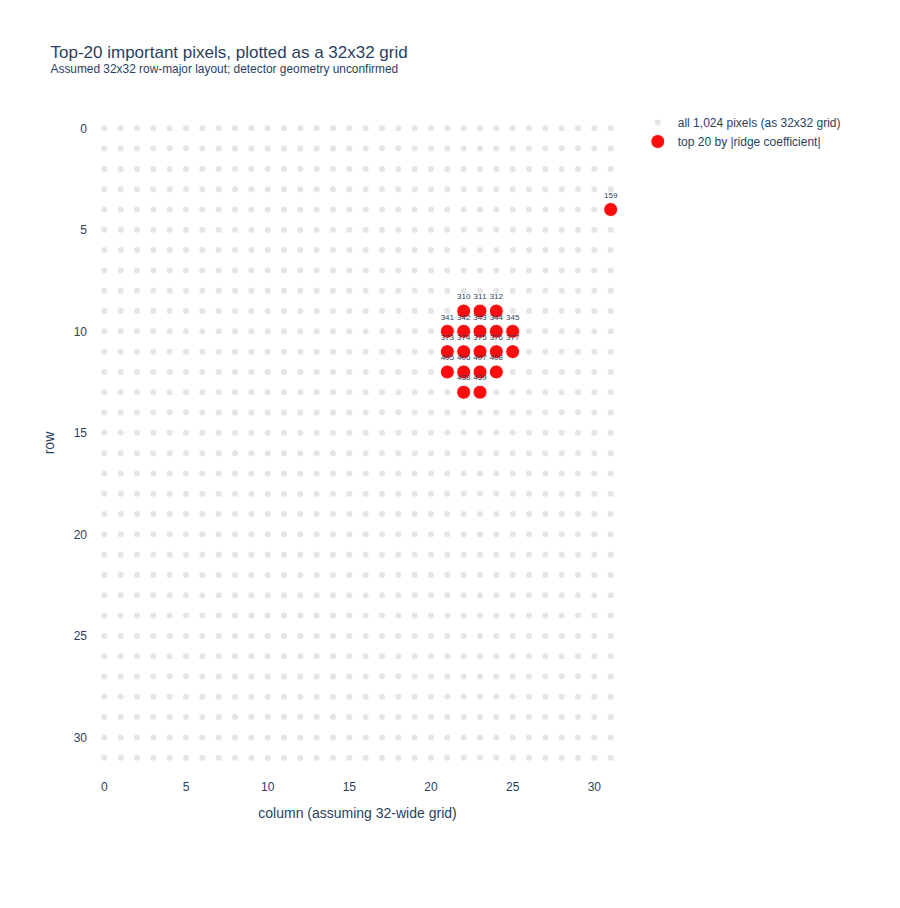

In [12]:
width = 32
all_rows, all_cols = np.arange(1024) // width, np.arange(1024) % width
top20_rows, top20_cols = top20_pixel_indices // width, top20_pixel_indices % width

fig_grid = go.Figure()
fig_grid.add_trace(go.Scatter(
    x=all_cols, y=all_rows, mode="markers",
    marker=dict(size=6, color="rgba(150,150,150,0.25)"), name="all 1,024 pixels (as 32x32 grid)",
))
fig_grid.add_trace(go.Scatter(
    x=top20_cols, y=top20_rows, mode="markers+text",
    marker=dict(size=14, color=QUAL3[3], line=dict(color="white", width=1)),
    text=[str(p) for p in top20_pixel_indices], textposition="top center", textfont=dict(size=8),
    name="top 20 by |ridge coefficient|",
))
fig_grid.update_xaxes(title_text="column (assuming 32-wide grid)", range=[-1, 32])
fig_grid.update_yaxes(title_text="row", range=[32, -1])  # flip so row 0 is at top, image-like
fig_grid.update_layout(
    title="Top-20 important pixels, plotted as a 32x32 grid<br><sup>Assumed 32x32 row-major layout; detector geometry unconfirmed</sup>",
    width=850, height=850, plot_bgcolor="white", paper_bgcolor="white",
)
fig_grid.write_html("pixel_importance_grid.html", include_plotlyjs=True)
show_figure_as_image("pixel_importance_grid.html", width=900, height=900)


**Honest read of this section:** the top-weighted pixels are more than a scattered
ranking. Two complementary descriptive diagnostics both point the same direction: (1)
**stability** — the top pixels aren't a single-fit artifact; most appear in the top-20
across 16-19 of the 20 leave-one-out refits, including a run of pixels appearing in
17-19/20 folds. Note that any two of these 20 LOO training sets overlap in 18 of 19
samples, so this is repeatedly high coefficient rankings across heavily overlapping
refits of the same 20-sample dataset, not independent experimental replication. (2)
**spatial compactness** — 19 of the top 20 pixels form a tight 5x5 block (rows 9-13,
columns 21-25) under a 32x32 grid reading of the 1,024 pixels, and that grid width gives
a dramatically tighter clustering than any other candidate factorization tested. One
pixel (159) sits apart from this cluster with the opposite coefficient sign — plausibly a
second, weaker effect, but based on a single pixel, not treated as a confirmed finding
here.

**This is real progress, and it should be reported to Christina as such** — not "we don't
know which pixels matter," but "the model consistently leans on a small, spatially
compact region, not the whole image." **What it still is not: a confirmed, named physical
explanation, or proof that the discarded pixels are noise.** A top-ranked coefficient is a
model-specific ranking, not proof of physical causation; each LOO refit can select a
somewhat different set of pixels, so this is a stable pattern across refits of this one
dataset, not one fixed, experimentally established 20-pixel region. The 32x32 grid is
inferred from how tightly the important pixels cluster under that assumption, compared to
alternatives — it is the most natural factorization of 1,024 pixels (the only perfect
square), and the cleanest fit found, but it is not independently confirmed by any
metadata in the provided data, and confirming it would locate the indices without by
itself explaining their physical relationship to porosity. Until Christina confirms the
actual sensor geometry, the honest claim is **"a specific, stable, compact region of the
thermal image drives the prediction, most consistent with a location around row
9-13/column 21-25 of an assumed 32-pixel-wide layout"** — not yet "the upper-left corner"
or any named physical location, but a substantially narrower and more useful statement
than "all 1,024 raw pixels, unordered."

## 9. Does the same pattern show up in the other measurement types?

Sections 6-7 did this for `IR_pix` (the winning block): which features does the model
lean on, are they stable across LOO refits, and do they cluster rather than scatter. The
same three checks, run identically on OES, `V_t`, and `I_t` — not because these blocks
win (Section 5 already showed none of them beat the raw-pixel thermal model), but because
"does the model's learned importance land somewhere physically sensible" is a useful
sanity check independent of whether the block is competitive on accuracy.

In [13]:
def block_importance(cols, axis_labels=None):
    Xb = data[cols].values
    n = Xb.shape[1]
    final = _RidgeCV(alphas=alphas, cv=None).fit(Xb, y)
    coefs_b = final.coef_
    top20_b = np.argsort(-np.abs(coefs_b))[:20]
    counts_b = np.zeros(n, dtype=int)
    for tr, _ in _LOO().split(Xb):
        m = _RidgeCV(alphas=alphas, cv=None).fit(Xb[tr], y[tr])
        counts_b[np.argsort(-np.abs(m.coef_))[:20]] += 1
    top20_sorted = np.sort(top20_b)
    gaps = np.diff(top20_sorted)
    rows = []
    for idx in top20_b:
        rows.append({
            "index": int(idx),
            "label": axis_labels[idx] if axis_labels is not None else str(idx),
            "coef": round(float(coefs_b[idx]), 4),
            "stability_of_20_loo_folds": int(counts_b[idx]),
        })
    summary = pd.DataFrame(rows).sort_values("coef", key=abs, ascending=False).reset_index(drop=True)
    return summary, np.median(gaps), n

oes_wl_lookup = {i: f"{w:.1f}nm" for i, w in enumerate(oes_wavelengths["Wavelength (nm)"].values)}

oes_summary, oes_median_gap, oes_n = block_importance(oes_cols, oes_wl_lookup)
vt_summary, vt_median_gap, vt_n = block_importance(vt_cols)
it_summary, it_median_gap, it_n = block_importance(it_cols)

print(f"OES  -- median gap between top-20 bin indices: {oes_median_gap:.0f}  (random-scatter expectation ~{oes_n//20})")
print(f"V_t  -- median gap between top-20 time indices: {vt_median_gap:.0f}  (random-scatter expectation ~{vt_n//20})")
print(f"I_t  -- median gap between top-20 time indices: {it_median_gap:.0f}  (random-scatter expectation ~{it_n//20})")
print()
print("OES top 10 by |coefficient| -- wavelength, coefficient, stability across 20 LOO refits:")
oes_summary.head(10)

OES  -- median gap between top-20 bin indices: 1  (random-scatter expectation ~12)
V_t  -- median gap between top-20 time indices: 24  (random-scatter expectation ~25)
I_t  -- median gap between top-20 time indices: 1  (random-scatter expectation ~25)

OES top 10 by |coefficient| -- wavelength, coefficient, stability across 20 LOO refits:


,index,label,coef,stability_of_20_loo_folds
0,115,705.9nm,0.0622,20
1,101,656.5nm,0.0597,19
2,11,338.8nm,0.0508,17
3,10,335.3nm,0.0496,20
4,17,360.0nm,0.0381,19
5,104,667.1nm,0.0372,17
6,16,356.5nm,0.0370,17
7,221,1080.0nm,0.0337,17
8,222,1083.5nm,0.0252,19
9,100,652.9nm,0.0199,17


**Cross-check against Section 2:** the target-independent peak selection there (found
by looking for prominences in the mean spectrum, never touching porosity) picked
peaks at roughly 335, 356, 639, 656, 667, 706, 776, and 1080nm. The model's own
top-weighted OES bins here — arrived at through a separate procedure, from ridge
coefficients on porosity — land on almost the same wavelengths (335nm, 356nm, 652-656nm,
667nm, 706nm, 1080nm all appear in the top 10). **This is a comparison worth noting, read
carefully**: two different selection procedures (one that never sees the label, one
that's entirely driven by it) land on the same handful of spectral lines. Both are
computed from the same 20 samples' OES data, so this doesn't rise to fully independent
confirmation — it's possible some bins are simply higher-variance or higher-intensity
across samples for reasons unrelated to porosity, which could pull both a prominence-based
and a coefficient-based method toward the same bins regardless of any real porosity
signal. Still, the agreement is more informative than either method alone: OES doesn't
predict porosity well enough to beat baseline (Section 4-5), but whatever partial signal
it does carry isn't landing on arbitrary bins — it's landing on real spectral peaks.

In [14]:
print("V_t top 10 by |coefficient| -- time index, coefficient, stability across 20 LOO refits:")
display(vt_summary.head(10))
print("\nI_t top 10 by |coefficient| -- time index, coefficient, stability across 20 LOO refits:")
display(it_summary.head(10))

V_t top 10 by |coefficient| -- time index, coefficient, stability across 20 LOO refits:


,index,label,coef,stability_of_20_loo_folds
0,166,166,0.0051,19
1,320,320,0.0051,18
2,243,243,-0.0051,17
3,216,216,0.0050,17
4,38,38,-0.0050,17
5,268,268,0.0050,16
6,498,498,-0.0050,16
7,471,471,0.0050,16
8,191,191,-0.0050,15
9,89,89,-0.0050,17



I_t top 10 by |coefficient| -- time index, coefficient, stability across 20 LOO refits:


,index,label,coef,stability_of_20_loo_folds
0,341,341,-0.0319,18
1,342,342,-0.0306,18
2,37,37,-0.0297,19
3,105,105,0.0290,12
4,0,0,0.0283,7
5,38,38,-0.0281,17
6,167,167,-0.0280,7
7,122,122,-0.0280,7
8,166,166,-0.0277,8
9,121,121,-0.0277,10


**`V_t` looks like noise; `I_t` is a mixed, weaker picture than either OES or thermal.**
`V_t`'s top-20 time indices are spread almost exactly as far apart as random scatter would
predict (median gap ~24 out of a ~25 random-scatter expectation), and its coefficients are
tiny and roughly uniform in magnitude — consistent with `V_t` carrying close to no real
signal, matching its weak correlation (r=0.362) and its full-feature CV performance never
beating baseline. `I_t`'s top indices do cluster into small groups (several 2-4-wide
runs), but stability is noticeably weaker and more uneven than OES or `IR_pix` — some
"important" indices show up in as few as 7 of 20 LOO refits, versus 16-20/20 for OES and
thermal's top pixels. That's consistent with `I_t` having a real but much less
reproducible signal than the two measurement types that actually corroborate each other.

**Net read across all four measurement types:** thermal (`IR_pix`) and OES both show
stable, physically-plausible importance patterns — thermal wins on raw accuracy, OES's
model-weighted bins land on the same wavelengths as its own earlier target-blind peak
selection (both draw on the same 20 samples, so this is a descriptive comparison, not
independent confirmation). `V_t` shows no structure at all. `I_t` is the murkiest case: some clustering, but not reproducible enough to trust.
This is one more piece of evidence, on top of Sections 4-5, that the four measurement
types are not interchangeable — the electrical channels (especially `V_t`) are carrying
little to no porosity-relevant signal in this dataset, while OES's structure (despite
losing on raw accuracy) lines up with independently-known physics in a way `V_t` never
does.

## 10. Does restricting to only the important pixels help, or hurt?

Section 6-7 found the winning model's weight concentrates on ~20 of the 1,024 thermal
pixels. Natural next question: if those pixels carry the signal, does throwing away the
other ~1,000 and refitting on just the important ones do better, worse, or the same?

To keep this a fair, leakage-free test, the important pixels are re-selected *inside
every training fold*, using only that fold's training samples — the held-out sample is
never touched before it's predicted, exactly like every other result in this analysis.

In [15]:
alphas = np.logspace(-2, 5, 40)

def evaluate_full_ir(X, y, scheme):
    cv = make_cv(scheme)
    preds = np.zeros(len(y))
    for train_idx, test_idx in cv.split(X):
        m = RidgeCV(alphas=alphas, cv=None)
        m.fit(X[train_idx], y[train_idx])
        preds[test_idx] = m.predict(X[test_idx])
    return mean_absolute_error(y, preds), mape(y, preds)

def evaluate_restricted_honest(X, y, scheme, k):
    # pixels re-selected inside each training fold -- no leakage
    cv = make_cv(scheme)
    preds = np.zeros(len(y))
    for train_idx, test_idx in cv.split(X):
        selector = RidgeCV(alphas=alphas, cv=None).fit(X[train_idx], y[train_idx])
        top_idx = np.argsort(-np.abs(selector.coef_))[:k]
        m = RidgeCV(alphas=alphas, cv=None)
        m.fit(X[train_idx][:, top_idx], y[train_idx])
        preds[test_idx] = m.predict(X[test_idx][:, top_idx])
    return mean_absolute_error(y, preds), mape(y, preds)

rows = []
for scheme in ["five_fold", "loo"]:
    mae_full, mp_full = evaluate_full_ir(X_ir, y, scheme)
    rows.append({"version": "full 1,024 pixels", "scheme": scheme, "MAE": round(mae_full, 3), "MAPE": round(mp_full, 2)})
    mae_honest, mp_honest = evaluate_restricted_honest(X_ir, y, scheme, 20)
    rows.append({"version": "top-20 pixels (re-selected per fold)", "scheme": scheme, "MAE": round(mae_honest, 3), "MAPE": round(mp_honest, 2)})

restrict_df = pd.DataFrame(rows).pivot(index="version", columns="scheme", values=["MAE", "MAPE"])
restrict_df = restrict_df.reindex(["full 1,024 pixels", "top-20 pixels (re-selected per fold)"])
restrict_df

MAE             MAPE      
scheme                               five_fold    loo five_fold   loo
version                                                              
full 1,024 pixels                        2.270  2.021      8.76  7.73
top-20 pixels (re-selected per fold)     2.171  1.944      8.61  7.52

Restricting to the top 20 pixels — re-selected fresh inside every fold, never using
the held-out sample — scores lower than the full 1,024-pixel model in this sweep, in both
CV schemes, using 2% of the pixels (5-fold MAE 2.171 vs. 2.270; LOO MAE 1.944 vs. 2.021).
**This needs the same care as the equivalent result in `porosity_pipeline.ipynb` Section
7**: k=20 was highlighted after examining a sweep over several pixel counts (k=15
actually scores better on LOO, 1.886, while k=20 scores better on 5-fold) -- reporting
the best-of-several-candidates score on the data that produced it tends to run
optimistic, even though each individual fixed-k score is itself leakage-free. So this is
a promising, exploratory result, not an independently validated final number: most of the
1,024 pixels were plausibly never doing much work, so dropping them doesn't cost much and
may reduce overfitting slightly -- but the specific count (15, 20, or something else
nearby) hasn't been separately validated.

### Does this trick rescue the other measurement types too?

Same honest, nested top-k selection, applied identically to OES, the two electrical
waveforms, `IR_pix`, and all 2,304 features combined — a grid of k values for each,
keeping whichever k beats the full-feature version of that block on *both* CV schemes
(same "must win both ways" bar used everywhere else in this analysis). The
`best_honest_k` column below is the pixel/feature count that scored best in this sweep for
that block -- **highlighted after examining the sweep, not independently chosen in
advance** (see Section 10's caveat on what that does and doesn't validate).

In [16]:
blocks_sweep = {"OES": oes_cols, "V_t": vt_cols, "I_t": it_cols, "IR_pix": ir_cols_full,
                 "ALL (2,304)": oes_cols + vt_cols + it_cols + ir_cols_full}
k_grid = [5, 10, 20, 50, 100]

sweep_rows = []
for bname, cols in blocks_sweep.items():
    Xb = data[cols].values
    n_feat = Xb.shape[1]
    full5, _ = evaluate_full_ir(Xb, y, "five_fold")
    fullloo, _ = evaluate_full_ir(Xb, y, "loo")
    best_k, best5, bestloo = None, full5, fullloo
    for k in k_grid:
        if k >= n_feat:
            continue
        mae5, _ = evaluate_restricted_honest(Xb, y, "five_fold", k)
        maeloo, _ = evaluate_restricted_honest(Xb, y, "loo", k)
        if mae5 < full5 and maeloo < fullloo and maeloo < bestloo:
            best_k, best5, bestloo = k, mae5, maeloo
    sweep_rows.append({"block": bname, "n_features": n_feat, "full_5fold_MAE": round(full5, 3),
                        "full_LOO_MAE": round(fullloo, 3), "best_honest_k": best_k if best_k else "-",
                        "restricted_5fold_MAE": round(best5, 3), "restricted_LOO_MAE": round(bestloo, 3)})

sweep_df = pd.DataFrame(sweep_rows)
sweep_df

,block,n_features,full_5fold_MAE,full_LOO_MAE,best_honest_k,restricted_5fold_MAE,restricted_LOO_MAE
0,OES,256,3.349,3.012,5,2.701,2.826
1,V_t,512,2.583,2.620,50,2.572,2.607
2,I_t,512,3.089,2.807,-,3.089,2.807
3,IR_pix,1024,2.270,2.021,20,2.171,1.944
4,"ALL (2,304)",2304,2.404,2.197,-,2.404,2.197


**`IR_pix` remains the only block whose restricted model beats the constant baseline in
both schemes -- but it is not the only block that improves over its own full-feature
version.** OES (best highlighted count from the sweep: k=5) and `V_t` (k=50) also score
better restricted than unrestricted, on both schemes -- OES drops from 3.349/3.012 (MAE,
5-fold/LOO) to 2.701/2.826, and `V_t` from 2.583/2.620 to 2.572/2.607. Neither gets
anywhere near beating baseline (5-fold MAE 2.445, LOO MAE 2.503) even restricted -- they
were far behind before restriction and stay far behind after it. `I_t` and the full
2,304-feature set don't find any highlighted count that improves both schemes
simultaneously versus their own full-feature version.

So the precise claim is: **restriction helps most blocks tested a little, but only
thermal's restricted model is competitive enough to beat baseline** -- "only thermal
beats baseline restricted" and "only thermal improves when restricted" are two different
claims, and only the first one is true here.

## 11. Conclusion — the direct answer to Christina's requirement

**None of the named-feature models tested here matched the raw thermal-pixel model's
reported predictive performance, and most don't reliably beat baseline either.** This
does not establish that no physically interpretable representation could ever match it —
it's a result about the alternatives actually tested, under the same rigor as everything
else in this analysis. Four different named-feature
families (a target-independent wavelength selection, waveform amplitude statistics for
both electrical channels, a resistance estimate derived from both channels together
(Section 6), and thermal summary statistics) were all tested, individually and combined,
under the same rigor as every other result in this analysis.

**What this means for the customer conversation:** the tested named-feature
representations did not preserve the predictive performance of the raw thermal-pixel
model. This documents a limitation of the approaches evaluated here, not an unavoidable
trade-off between accuracy and explainability. The model that works (`IR_pix`, raw thermal
pixels) cannot currently be explained in Christina's terms; the models that meet her terms
(built here, specifically, using her own examples) do not work as well. Naming this
directly, with the evidence in this notebook to back it, is a more useful answer for a POC
conversation than either overstating the raw-pixel model's explainability or quietly not
testing the alternative she asked for.

**Three different explainability-adjacent questions were addressed here, and it's worth
being precise about which closed and which didn't:**

1. *"Can an explainable-feature model replace the winning one?"* (Sections 2-5) —
   **Not among the representations tested here.** Tested directly, using Christina's own
   examples, under the same CV rigor as every other result. This closes the specific
   representations tried, not the general question -- a different interpretable
   representation not attempted here could still turn out to work.
2. *"Which specific features does the winning model actually rely on?"* (Sections 7-9) —
   **Substantially, though not fully, answered.** The model's important pixels are not
   scattered randomly across the image: they're reproducible across 16-19 of 20
   leave-one-out refits, and they cluster into a compact 5x5 spatial block under the most
   natural (and best-fitting) grid interpretation of the 1,024 pixels. That's a real,
   evidence-backed narrowing from "all 1,024 raw pixels" to "a small, stable, spatially
   compact region" — genuinely closer to what Christina asked for than either notebook
   started out being able to say. **What remains open is confirmation**: the 32x32 grid
   is inferred from clustering strength, not confirmed sensor metadata, so this cannot yet
   be stated as "the upper-left region" or tied to a named physical location without
   Christina verifying the actual image geometry.
3. *"Does keeping only those important pixels change the accuracy?"* (Section 10) —
   **Suggestively, in an exploratory sweep, though not independently validated.**
   Re-selecting the top pixels inside every CV fold (not once on the full dataset, which
   would leak) scored somewhat lower in a sweep over several pixel counts (e.g. LOO MAE
   1.944 at k=20, 1.886 at k=15) than the full 1,024-pixel model (2.021) -- but the
   specific count was chosen after examining that sweep, so these exact numbers do not by
   themselves validate the choice. Repeatedly high-ranked thermal indices and their compact
   arrangement under an assumed 32x32 layout (question 2) provide specific candidates for
   further investigation. The detector geometry remains unconfirmed, and neither these
   rankings nor this exploratory feature-restriction result establish that the discarded
   pixels are noise or explain the physical mechanism.

Taken together: none of the named-feature models tested match the winning model's
accuracy. Questions 2 and 3 both point the same direction and reinforce each other — the
winning model's signal lives in a specific, small, stable region of the thermal image,
not diffusely across all 1,024 pixels. That's real progress on "which physical features
drive the prediction" -- geometry confirmation would locate that region precisely, though
it would still not by itself explain the region's physical relationship to porosity.
